# Tarea 3: Cross-Dataset Ecological Modeling

IELE756 – Preparación y Análisis de Datos

Team members: Catalina Cornejo, Javiera García

Date: Thursday, April 30, 2026

Comunas: Renca, Lo Barnechea, Buin


## Part 0: Building the Analytical Table 

### 0.1 Class-pooled master table

In this section, the CSV files uploaded by all teams are combined into three master tables: one for Census, one for ENO, and one for GRD. Since each team worked with only a small number of comunas, pooling the class files allows the analysis to be performed at a broader comuna level.

The objective of this step is to verify whether the three sources contain consistent comuna coverage before merging them into a single analytical dataset. For this reason, the row count, number of unique `codigo_comuna` values, missing comuna codes, duplicated comuna codes, and differences in comuna coverage across datasets are checked.

If any team file is missing or malformed, the analysis continues with the available data, while explicitly reporting the final number of comunas used in later sections.

In [1]:
# Part 0.1 - Load and concatenate class-pooled CSV files

import pandas as pd
import numpy as np
import glob
import os

shared_path = "shared"

# Find files
census_files = glob.glob(os.path.join(shared_path, "census_team*.csv"))
eno_files = glob.glob(os.path.join(shared_path, "eno_team*.csv"))
grd_files = glob.glob(os.path.join(shared_path, "grd_team*.csv"))

print("Number of Census files:", len(census_files))
print("Number of ENO files:", len(eno_files))
print("Number of GRD files:", len(grd_files))

# Load and concatenate
census_master = pd.concat([pd.read_csv(f) for f in census_files], ignore_index=True)
eno_master = pd.concat([pd.read_csv(f) for f in eno_files], ignore_index=True)
grd_master = pd.concat([pd.read_csv(f) for f in grd_files], ignore_index=True)

# Basic sanity checks
def check_master(df, name):
    print(f"\n{name}")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("Unique codigo_comuna:", df["codigo_comuna"].nunique())
    print("Missing codigo_comuna:", df["codigo_comuna"].isna().sum())
    
    duplicated = df[df.duplicated(subset="codigo_comuna", keep=False)].sort_values("codigo_comuna")
    print("Duplicated codigo_comuna rows:", duplicated.shape[0])
    
    if duplicated.shape[0] > 0:
        display(duplicated)

check_master(census_master, "CENSUS MASTER")
check_master(eno_master, "ENO MASTER")
check_master(grd_master, "GRD MASTER")

Number of Census files: 20
Number of ENO files: 20
Number of GRD files: 20

CENSUS MASTER
Rows: 51
Columns: 15
Unique codigo_comuna: 46
Missing codigo_comuna: 2
Duplicated codigo_comuna rows: 8


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio,Comuna Nombre,comuna
22,13105.0,Estación Central,155257.0,142967.0,11347.0,7.300000,37.0,32.0,10.960000,12.194000,58.800000,71.700000,0.497000,NaN,NaN
29,13105.0,El Bosque,155257.0,143714.0,10652.0,6.860882,37.0,31.0,10.971926,12.114083,58.937127,71.021600,0.497001,NaN,NaN
46,13109.0,La Cisterna,103157.0,82209.0,19762.0,19.157207,37.0,32.0,12.724804,13.401107,0.674023,0.787796,0.447939,NaN,NaN
5,13109.0,La Reina,103157.0,82209.0,19762.0,19.380000,37.0,32.0,12.910000,13.560000,67.500000,78.900000,44.800000,NaN,NaN
6,13122.0,Quilicura,236478.0,214770.0,20141.0,8.570000,38.0,35.0,12.190000,13.060000,64.600000,77.800000,43.500000,NaN,NaN
1,13122.0,Peñalolén,236478.0,216664.0,18304.0,7.740255,38.0,34.0,12.222864,12.847696,64.719587,77.567496,43.493061,NaN,NaN
49,NaN,NaN,91290.0,78678.0,12110.0,13.265418,41.0,34.0,11.056758,12.004300,0.625905,0.754180,0.475465,Lo Prado,13117.0
50,NaN,NaN,227820.0,210831.0,15344.0,6.735142,37.0,33.0,11.692555,12.441822,0.619386,0.738583,0.428643,Pudahuel,13124.0



ENO MASTER
Rows: 51
Columns: 11
Unique codigo_comuna: 46
Missing codigo_comuna: 2
Duplicated codigo_comuna rows: 8


,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k,codigo_comuna_residencia,Comuna Nombre,pop_total
1,13105.0,Estación Central,1212,634,111,467,VIH | Parotiditis | Coqueluche,78.060000,NaN,NaN,NaN
12,13105.0,El Bosque,1212,634,111,467,"VIH, Parotiditis, Coqueluche",78.064113,NaN,NaN,NaN
21,13109.0,La Reina,714,333,149,232,VIH | Parotiditis | Coqueluche,69.210000,NaN,NaN,NaN
39,13109.0,La Cisterna,714,333,149,232,VIH | Parotiditis | Coqueluche,69.214886,NaN,NaN,NaN
22,13122.0,Quilicura,1487,701,124,662,VIH | Parotiditis | Coqueluche,62.880000,NaN,NaN,NaN
26,13122.0,Peñalolén,1487,701,124,662,VIH | Parotiditis | Coqueluche,62.880000,NaN,NaN,NaN
29,NaN,NaN,591,442,149,0,"VIH, Sifilis, Parotiditis",64.738745,13117.0,Lo Prado,91290.0
30,NaN,NaN,1051,882,169,0,"VIH, Sifilis, Parotiditis",46.132912,13124.0,Pudahuel,227820.0



GRD MASTER
Rows: 51
Columns: 16
Unique codigo_comuna: 48
Missing codigo_comuna: 0
Duplicated codigo_comuna rows: 6


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k,COMUNA,nombre_comuna_upper,pop_total
7,13105,El Bosque,9517,9046,471,4.949039,7.223915,7.369335,4.430998,1.774614,3.425449,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",612.983634,NaN,NaN,NaN
16,13105,Estación Central,17446,12314,5132,29.420000,6.530000,7.220000,4.870000,1.650000,2.720000,Cap.15 EMBARAZO | PARTO Y PUERPERIO (O00-O9A)...,1123.690000,NaN,NaN,NaN
30,13109,La Reina,5004,4692,312,6.240000,5.380000,5.480000,3.850000,1.382000,2.618000,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,485.090000,NaN,NaN,NaN
38,13109,La Cisterna,7338,6249,1089,0.148406,6.360998,6.642663,4.744720,1.610793,0.037885,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",711.342905,NaN,NaN,NaN
27,13122,Peñalolén,44917,42047,2870,6.390000,5.340000,5.430000,4.140000,1.560000,2.910000,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,1899.420000,NaN,NaN,NaN
31,13122,Quilicura,13062,11120,1942,14.870000,5.900000,6.170000,4.400000,1.393000,2.167000,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",552.360000,NaN,NaN,NaN


After concatenating the class-pooled datasets, some rows were found to have missing `codigo_comuna` and `nombre_comuna` values. 

Inspection of these cases showed that the comuna information was not actually missing, but instead stored in incorrectly named columns (such as `comuna`, `Comuna Nombre`, or `codigo_comuna_residencia`) in some team submissions.

To standardize the structure across all files, these alternative columns are used to fill the missing values, and then removed to ensure a consistent schema before proceeding with further checks.

In [2]:
# Fix malformed census files
if "comuna" in census_master.columns:
    census_master["codigo_comuna"] = census_master["codigo_comuna"].fillna(census_master["comuna"])

if "Comuna Nombre" in census_master.columns:
    census_master["nombre_comuna"] = census_master["nombre_comuna"].fillna(census_master["Comuna Nombre"])

# Fix malformed ENO files
if "codigo_comuna_residencia" in eno_master.columns:
    eno_master["codigo_comuna"] = eno_master["codigo_comuna"].fillna(eno_master["codigo_comuna_residencia"])

if "Comuna Nombre" in eno_master.columns:
    eno_master["nombre_comuna"] = eno_master["nombre_comuna"].fillna(eno_master["Comuna Nombre"])

# Drop extra malformed columns
census_master = census_master.drop(columns=["comuna", "Comuna Nombre"], errors="ignore")
eno_master = eno_master.drop(columns=["codigo_comuna_residencia", "Comuna Nombre", "pop_total"], errors="ignore")
grd_master = grd_master.drop(columns=["COMUNA", "nombre_comuna_upper", "pop_total"], errors="ignore")

# Ensure comuna code is numeric/int
census_master["codigo_comuna"] = census_master["codigo_comuna"].astype(int)
eno_master["codigo_comuna"] = eno_master["codigo_comuna"].astype(int)
grd_master["codigo_comuna"] = grd_master["codigo_comuna"].astype(int)

In [3]:
def deep_check(df, name):
    print(f"\n===== {name} =====")
    
    # 1. Check rows with missing comuna code or comuna name
    null_rows = df[df["codigo_comuna"].isna() | df["nombre_comuna"].isna()]
    print("Rows with missing comuna info:", null_rows.shape[0])
    
    if null_rows.shape[0] > 0:
        display(null_rows.head())

    # 2. Check duplicated comuna codes
    dup = df[df.duplicated("codigo_comuna", keep=False)].sort_values("codigo_comuna")
    print("Duplicated codigo_comuna:", dup["codigo_comuna"].nunique())
    
    if dup.shape[0] > 0:
        display(dup[["codigo_comuna", "nombre_comuna"]])

    # 3. Check whether the same code is assigned to different comuna names
    inconsistent = df.groupby("codigo_comuna")["nombre_comuna"].nunique()
    inconsistent = inconsistent[inconsistent > 1]
    
    print("Codes with multiple names:", len(inconsistent))
    
    if len(inconsistent) > 0:
        display(
            df[df["codigo_comuna"].isin(inconsistent.index)]
            [["codigo_comuna", "nombre_comuna"]]
            .sort_values("codigo_comuna")
        )

    # 4. Report final row count and number of unique comuna codes
    print("Total rows:", df.shape[0])
    print("Unique comunas:", df["codigo_comuna"].nunique())

In [4]:
deep_check(census_master, "CENSUS")
deep_check(eno_master, "ENO")
deep_check(grd_master, "GRD")


===== CENSUS =====
Rows with missing comuna info: 0
Duplicated codigo_comuna: 3


,codigo_comuna,nombre_comuna
22,13105,Estación Central
29,13105,El Bosque
46,13109,La Cisterna
5,13109,La Reina
6,13122,Quilicura
1,13122,Peñalolén


Codes with multiple names: 3


,codigo_comuna,nombre_comuna
22,13105,Estación Central
29,13105,El Bosque
46,13109,La Cisterna
5,13109,La Reina
6,13122,Quilicura
1,13122,Peñalolén


Total rows: 51
Unique comunas: 48

===== ENO =====
Rows with missing comuna info: 0
Duplicated codigo_comuna: 3


...

Total rows: 51
Unique comunas: 48

===== GRD =====
Rows with missing comuna info: 0
Duplicated codigo_comuna: 3


,codigo_comuna,nombre_comuna
7,13105,El Bosque
16,13105,Estación Central
30,13109,La Reina
38,13109,La Cisterna
27,13122,Peñalolén
31,13122,Quilicura


Codes with multiple names: 3


,codigo_comuna,nombre_comuna
7,13105,El Bosque
16,13105,Estación Central
30,13109,La Reina
38,13109,La Cisterna
27,13122,Peñalolén
31,13122,Quilicura


Total rows: 51
Unique comunas: 48


The deeper sanity check showed that the missing comuna information had already been solved, but three comuna codes were still duplicated and linked to different comuna names in all three datasets: 13105, 13109, and 13122.

To avoid manually changing comuna codes and potentially introducing new errors, we used the official comuna code dictionary only to identify which rows had the correct code-name assignment. Then, kept only the rows where the comuna name matched the official code and removed the inconsistent rows.

This decision preserves only reliable observations and ensures that each `codigo_comuna` appears once before comparing coverage across Census, ENO, and GRD.

In [7]:
official_comuna_names = {
    13105: "El Bosque",
    13109: "La Cisterna",
    13122: "Peñalolén"
}

def keep_correct_rows(df):
    # Identify rows affected by the inconsistent code-name assignments
    mask = df["codigo_comuna"].isin(official_comuna_names.keys())
    
    # Keep unaffected rows and affected rows only when the name matches the official code
    correct = df[
        (~mask) | 
        (df["nombre_comuna"] == df["codigo_comuna"].map(official_comuna_names))
    ]
    
    return correct

# Apply the filtering rule to each master table
census_master = keep_correct_rows(census_master)
eno_master = keep_correct_rows(eno_master)
grd_master = keep_correct_rows(grd_master)

# Remove any remaining duplicated comuna codes
census_master = census_master.drop_duplicates("codigo_comuna")
eno_master = eno_master.drop_duplicates("codigo_comuna")
grd_master = grd_master.drop_duplicates("codigo_comuna")

In [9]:
# Compare comuna coverage

census_set = set(census_master["codigo_comuna"].dropna())
eno_set = set(eno_master["codigo_comuna"].dropna())
grd_set = set(grd_master["codigo_comuna"].dropna())

print("Census not in ENO:", census_set - eno_set)
print("Census not in GRD:", census_set - grd_set)

print("ENO not in Census:", eno_set - census_set)
print("GRD not in Census:", grd_set - census_set)

Census not in ENO: set()
Census not in GRD: set()
ENO not in Census: set()
GRD not in Census: set()


In [10]:
# Check own comunas

my_comunas = [13115, 13128, 13402]

print("\nCENSUS")
display(census_master[census_master["codigo_comuna"].isin(my_comunas)])

print("\nENO")
display(eno_master[eno_master["codigo_comuna"].isin(my_comunas)])

print("\nGRD")
display(grd_master[grd_master["codigo_comuna"].isin(my_comunas)])


CENSUS


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
38,13115,Lo Barnechea,112620.0,98589.0,12198.0,10.831113,34.0,42.0,14.868803,15.031679,63.152090,73.112093,45.969697
39,13128,Renca,143622.0,130218.0,12523.0,8.719416,35.0,33.0,10.895060,12.027874,61.276611,72.134725,47.257795
40,13402,Buin,116969.0,110229.0,5960.0,5.095367,34.0,34.0,12.185436,13.374942,63.132818,72.907216,46.352114



ENO


,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
47,13115,Lo Barnechea,630,278,42,310,Parotiditis | Coqueluche | VIH,55.94
48,13128,Renca,1064,590,113,361,VIH | Parotiditis | Coqueluche,74.08
49,13402,Buin,551,251,34,266,Parotiditis | VIH | Coqueluche,47.11



GRD


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
42,13402,Buin,15457,14669,788,5.10,5.576291,5.603302,5.086142,1.488646,2.956589,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,1321.461242
43,13115,Lo Barnechea,6883,6204,679,9.86,5.166742,5.239609,4.483568,1.425977,1.772483,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",611.170307
44,13128,Renca,25748,24002,1746,6.78,6.392185,6.495590,4.999133,1.464696,3.068199,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",1792.761555


After concatenating the class-pooled datasets, the initial checks revealed inconsistencies in the comuna identifiers across all three sources. In particular, some comuna codes were duplicated and assigned to different comuna names, and some rows had missing identifiers stored in alternative columns.

These issues were addressed in two steps. First, missing comuna information was recovered from alternative columns (e.g., `Comuna Nombre`, `comuna`, and `codigo_comuna_residencia`) to standardize the schema across all files. Second, for the duplicated comuna codes (13105, 13109, and 13122), only the rows with correct code-name assignments according to the official dictionary were kept, and inconsistent rows were removed.

After cleaning, each master table contains one row per `codigo_comuna`, with no missing identifiers and consistent code-name mappings.

The comparison of comuna coverage shows no differences between Census, ENO, and GRD, as all set differences are empty. This indicates that the three datasets now cover the same set of comunas.

Finally, the assigned comunas (Lo Barnechea, Renca, and Buin) are present in all three datasets, and their values match the results obtained in Tareas 1 and 2. Therefore, these observations are considered reliable.

The final number of comunas used for downstream analysis is 48.
No missing comunas were imputed; inconsistent rows were removed, resulting in a reduced but reliable sample.

### 0.2 Merge on codigo_comuna

In this section, the three master tables (Census, ENO, and GRD) are merged into a single analytical dataset using `codigo_comuna` as the key.

Since inconsistencies were identified in the previous step (duplicates, missing comuna codes, and asymmetric coverage), special care is taken in choosing the merge strategy. The goal is to retain one row per comuna while preserving as much information as possible across datasets.

The merge process is performed step by step, and the shape of the dataset is reported after each merge. Additionally, any comunas lost during the merging process are explicitly identified and discussed.

In [11]:
# Step 1: Drop duplicates BEFORE merging (keep first occurrence)

census_clean = census_master.drop_duplicates(subset="codigo_comuna")
eno_clean = eno_master.drop_duplicates(subset="codigo_comuna")
grd_clean = grd_master.drop_duplicates(subset="codigo_comuna")

print("Shapes after removing duplicates:")
print("Census:", census_clean.shape)
print("ENO:", eno_clean.shape)
print("GRD:", grd_clean.shape)


# Step 2: Merge step by step (outer merge to avoid losing comunas)

merge_ce = pd.merge(census_clean, eno_clean, on="codigo_comuna", how="outer", suffixes=("_census", "_eno"))
print("\nAfter merging Census + ENO:", merge_ce.shape)

final_df = pd.merge(merge_ce, grd_clean, on="codigo_comuna", how="outer")
print("After merging with GRD:", final_df.shape)


# Step 3: Check which comunas are lost or added

final_set = set(final_df["codigo_comuna"].dropna())

print("\nComunas in final dataset:", len(final_set))

print("Lost from Census:", census_set - final_set)
print("Lost from ENO:", eno_set - final_set)
print("Lost from GRD:", grd_set - final_set)

Shapes after removing duplicates:
Census: (48, 13)
ENO: (48, 8)
GRD: (48, 13)

After merging Census + ENO: (48, 20)
After merging with GRD: (48, 32)

Comunas in final dataset: 48
Lost from Census: set()
Lost from ENO: set()
Lost from GRD: set()


In [12]:
# Rows with codigo_comuna NaN
final_df[final_df["codigo_comuna"].isna()]

,codigo_comuna,nombre_comuna_census,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,...,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k


After removing duplicated `codigo_comuna` entries within each dataset, the resulting tables contain 48 comunas in Census, ENO, and GRD.

The datasets were merged using an outer join to preserve all available information. After merging Census and ENO, the dataset contains 48 rows. After incorporating GRD, the final dataset contains 48 rows and 48 unique comunas.

No rows with missing `codigo_comuna` remain in the final dataset, and no comunas are lost during the merge process, as all set differences are empty.

This confirms that the merge strategy successfully preserves one row per comuna while integrating information from all three sources.

### 0.3 Derived variables

In this section, comuna-level covariates are constructed from the Census variables and added to the analytical dataset.

The selected covariates capture key demographic and socioeconomic characteristics of each comuna, including population size, migration composition, labor market conditions, and educational differences between Chilean-born and foreign-born populations.

The following variables are included:

pct_foreign: percentage of foreign-born population (already provided)  
log_pop_total: natural logarithm of total population  
pct_unemployed: proportion of unemployed population, derived as one minus the employment rate  
schooling_gap: difference in mean years of schooling between Chilean-born and foreign-born populations  

Additionally, one extra covariate is constructed to enrich the analysis:

emp_gap: difference in employment rates between Chilean-born and foreign-born populations  

All variables are computed at the comuna level and appended to the analytical dataset.

In [15]:
# Create derived variables

df = final_df.copy()

# Clean pct_foreign while keeping the original column
df["pct_foreign_clean"] = df["pct_foreign"].copy()

df.loc[df["pct_foreign_clean"] > 100, "pct_foreign_clean"] = np.nan

mask = df["pct_foreign_clean"].between(0, 1)
df.loc[mask, "pct_foreign_clean"] = df.loc[mask, "pct_foreign_clean"] * 100

# 1. Log of total population
df["log_pop_total"] = np.log(df["pop_total"])

# 2. Unemployment proxy
df["emp_rate_avg"] = (df["emp_rate_chilean"] + df["emp_rate_foreign"]) / 2
df["pct_unemployed"] = 1 - (df["emp_rate_avg"] / 100)

# 3. Schooling gap
df["schooling_gap"] = df["mean_schooling_chilean"] - df["mean_schooling_foreign"]

# 4. Additional covariate: employment gap
df["emp_gap"] = df["emp_rate_chilean"] - df["emp_rate_foreign"]

# Check selected variables
df[[
    "codigo_comuna",
    "pct_foreign",
    "pct_foreign_clean",
    "log_pop_total",
    "pct_unemployed",
    "schooling_gap",
    "emp_gap"
]].head()

,codigo_comuna,pct_foreign,pct_foreign_clean,log_pop_total,pct_unemployed,schooling_gap,emp_gap
0,5101,4.320000,4.320000,12.560027,0.414500,-0.500000,-9.300000
1,5102,7.590000,7.590000,10.304811,0.359000,0.500000,-15.400000
2,13101,3047.812608,NaN,8.666647,0.220004,0.616190,-10.681846
3,13102,15.000000,15.000000,11.350889,0.348500,0.286000,-8.700000
4,13104,14.545963,14.545963,11.708385,0.993195,-0.658586,-0.141000


Several comuna-level covariates were constructed from the Census variables and added to the analytical dataset.

First, the natural logarithm of total population (`log_pop_total`) was computed to capture differences in comuna size while reducing skewness.

Second, the unemployment rate (`pct_unemployed`) was derived as one minus the average employment rate across Chilean-born and foreign-born populations. This provides a proxy for labor market conditions at the comuna level.

Third, the schooling gap (`schooling_gap`) was calculated as the difference between mean years of schooling for Chilean-born and foreign-born populations. Positive values indicate higher schooling among Chileans, while negative values indicate higher schooling among foreign-born populations.

Additionally, an employment gap (`emp_gap`) was constructed to capture differences in employment rates between both groups.

During this process, an inconsistency was identified in the `pct_foreign` variable: one value was implausibly above 100. To ensure consistency, the variable was cleaned by setting implausible values to missing. The cleaned version (`pct_foreign_clean`) is used in subsequent analyses.

These transformations ensure that all covariates are comparable across comunas.

## Part 1: Exploratory Cross-Dataset Analysis 

### 1.1 Correlation matrix

In this section, a Pearson correlation matrix is computed to explore the relationships between demographic covariates and health outcomes at the comuna level. The matrix includes Census-derived variables and the two primary outcomes: eno_rate_per_10k and grd_rate_per_10k. The results are visualized using a heatmap.

Rows used for correlation: 44


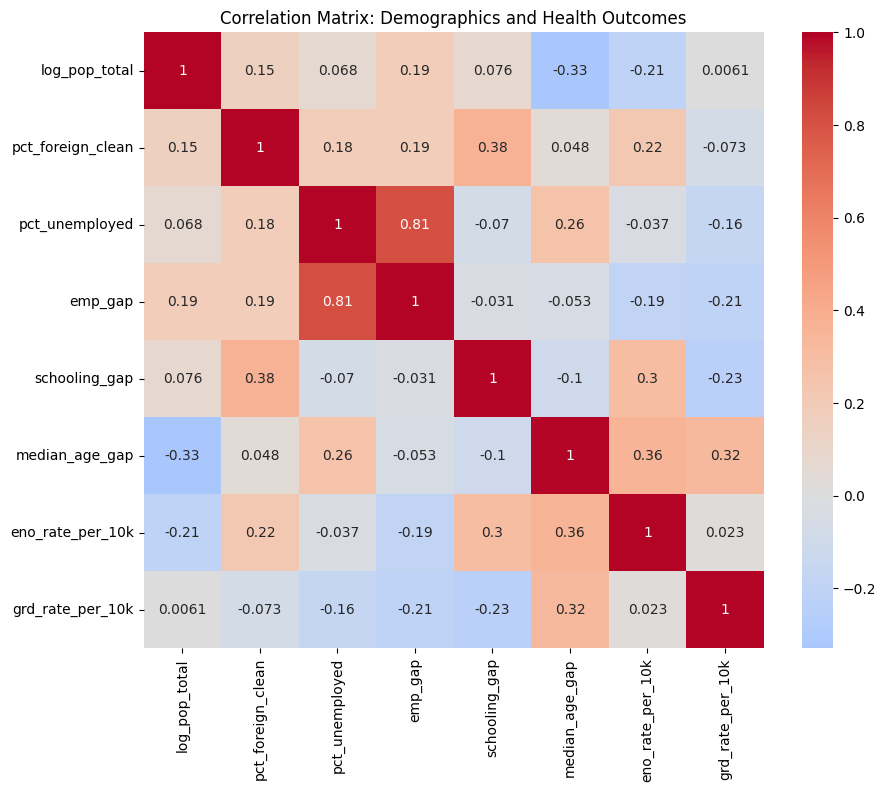

In [17]:
# Create additional covariate: age gap
df["median_age_gap"] = df["median_age_chilean"] - df["median_age_foreign"]

# Select variables (ordered to group related concepts)
corr_vars = [
    "log_pop_total",        # population size
    "pct_foreign_clean",    # migration composition
    "pct_unemployed",       # labor market condition
    "emp_gap",              # employment difference
    "schooling_gap",        # education difference
    "median_age_gap",       # age structure difference
    "eno_rate_per_10k",     # ENO health outcome
    "grd_rate_per_10k"      # GRD health outcome
]

# Drop rows with missing values
corr_df = df[corr_vars].dropna()

print("Rows used for correlation:", corr_df.shape[0])

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Demographics and Health Outcomes")
plt.show()

The correlation matrix is computed using 44 comunas after removing rows with missing values. Overall, most correlations are moderate or weak, suggesting that no single demographic variable strongly determines health outcomes at the comuna level.

The strongest correlation observed is between pct_unemployed and emp_gap (0.81). This is expected, as both variables capture closely related labor market dynamics: higher unemployment is naturally associated with larger differences in employment rates across population groups.

The next strongest correlations involve median_age_gap:

median_age_gap and eno_rate_per_10k (0.36): comunas where the age difference between Chilean-born and foreign-born populations is larger tend to exhibit higher ENO notification rates. This is consistent with the idea that age structure may influence disease exposure and reporting patterns.

median_age_gap and grd_rate_per_10k (0.32): a similar positive relationship is observed for GRD rates, suggesting that age composition may also be associated with hospitalization patterns.

Additionally, a moderate positive correlation is observed between pct_foreign_clean and schooling_gap (0.38), suggesting that comunas with higher shares of foreign-born population tend to exhibit larger differences in schooling between Chilean-born and foreign-born groups.

Overall, the signs of these correlations are broadly consistent with expectations. However, the relatively modest magnitudes suggest that these relationships are not strong on their own and should be further explored using multivariate models.


### 1.2 Bivariate scatter plots

To further explore the relationship between demographic characteristics and health outcomes, a set of bivariate scatter plots is produced.

Each plot shows one Census-derived covariate on the x-axis and one health outcome (`eno_rate_per_10k` or `grd_rate_per_10k`) on the y-axis. A simple OLS regression line is overlaid to highlight the general trend.

To improve interpretability, the five comunas with the largest residuals (i.e., those that deviate most from the fitted relationship) are identified and labeled in each plot. These observations are useful for detecting outliers and potential sources of heterogeneity across comunas.

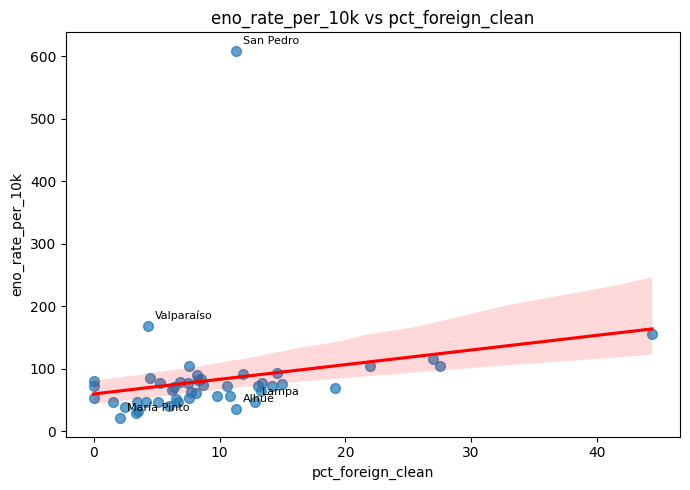

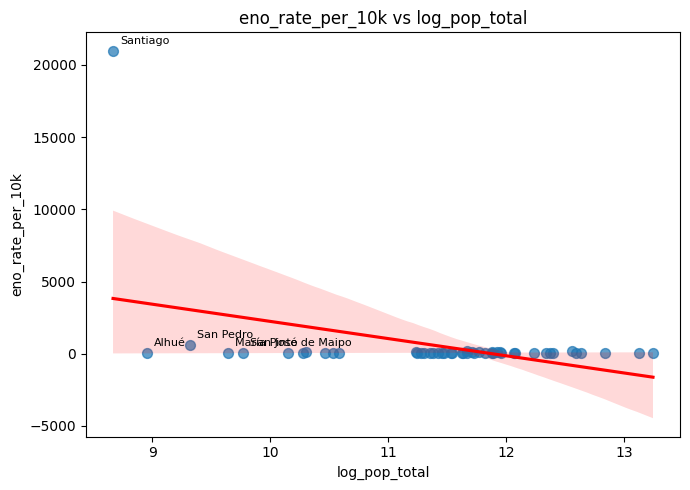

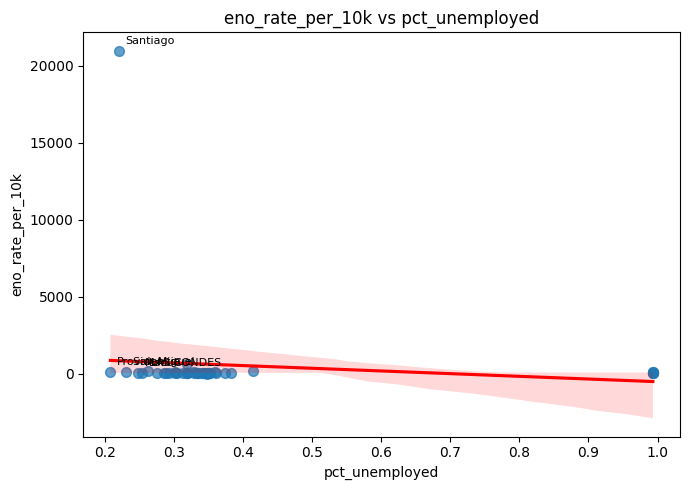

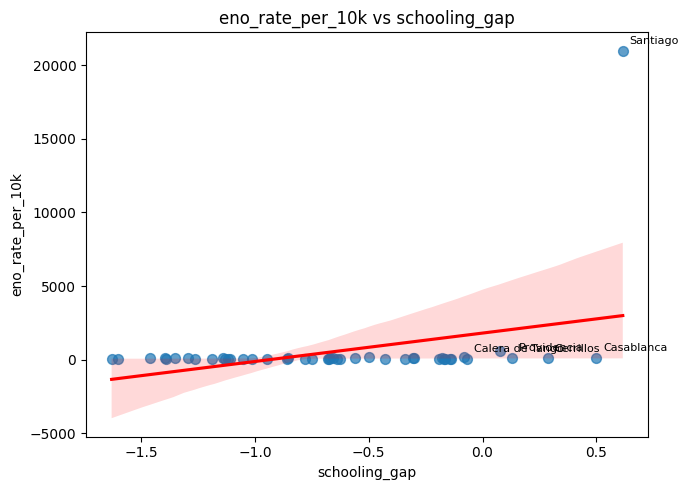

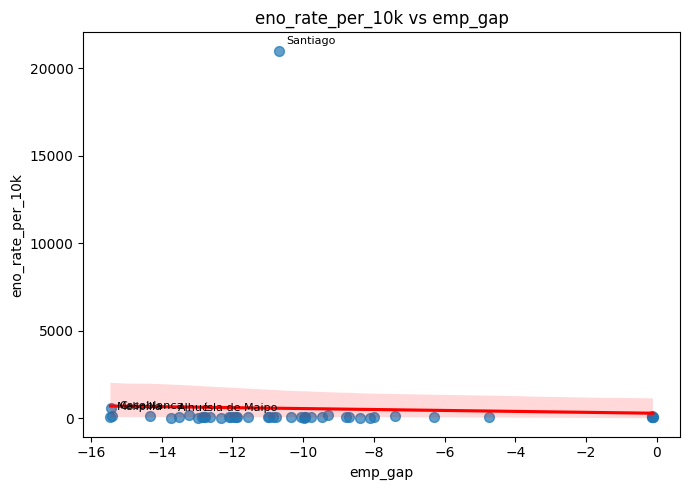

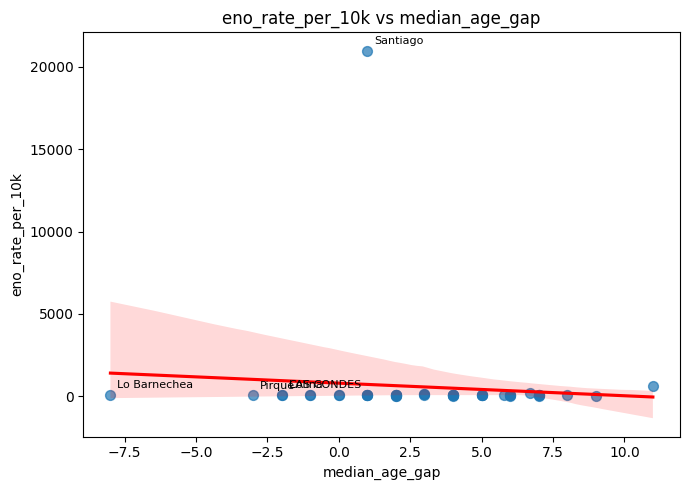

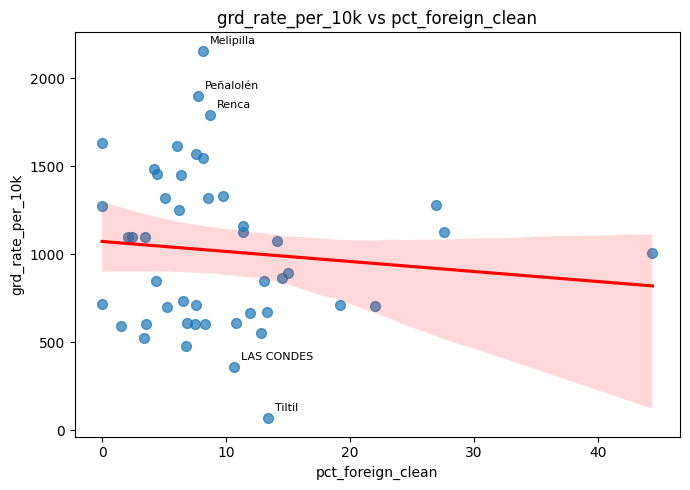

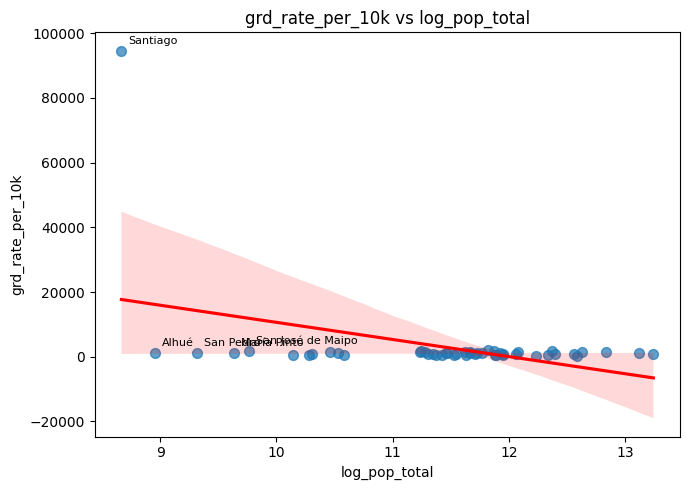

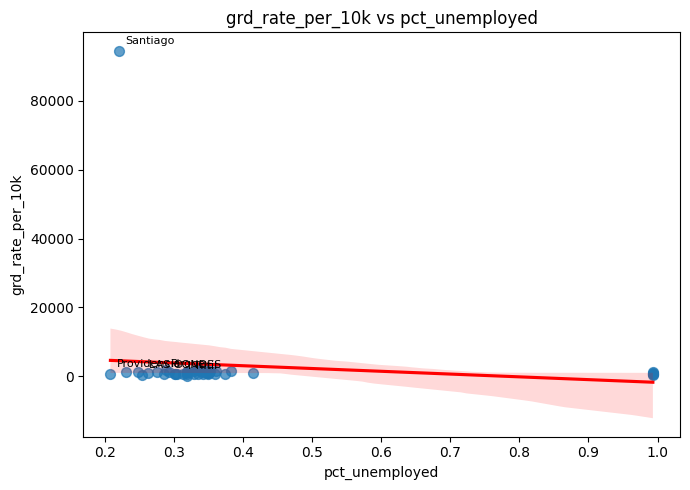

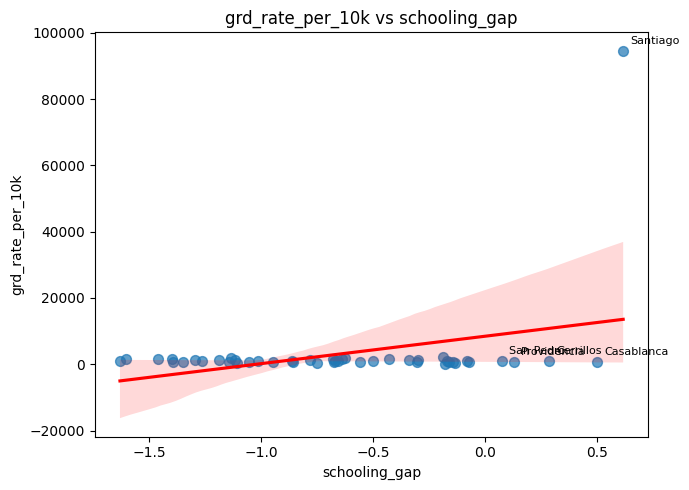

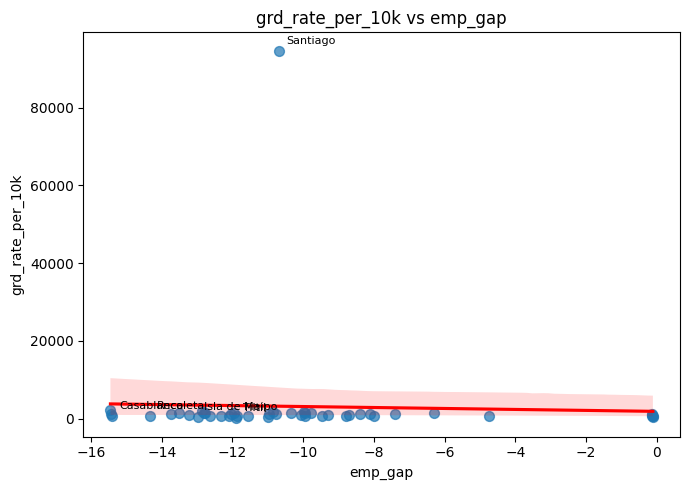

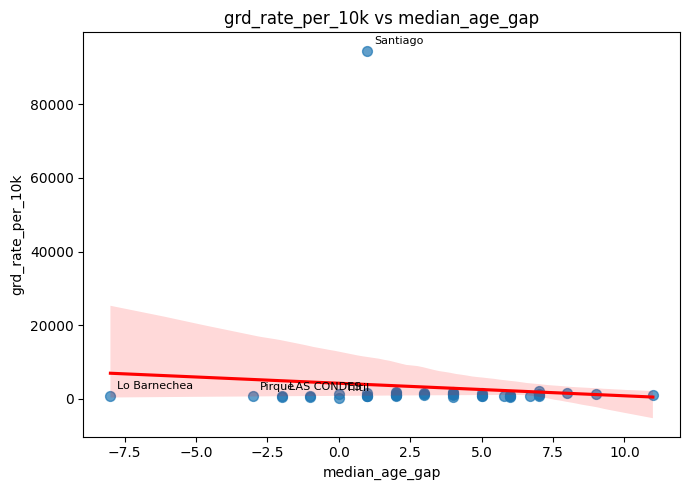

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

covariates = [
    "pct_foreign_clean",
    "log_pop_total",
    "pct_unemployed",
    "schooling_gap",
    "emp_gap",
    "median_age_gap"
]

outcomes = ["eno_rate_per_10k", "grd_rate_per_10k"]

for y in outcomes:
    for x in covariates:
        
        temp = df[[x, y, "nombre_comuna_census"]].dropna()
        
        if temp.shape[0] < 10:
            continue
        
        # Fit line
        coef = np.polyfit(temp[x], temp[y], 1)
        pred = np.polyval(coef, temp[x])
        residuals = temp[y] - pred
        
        temp["residuals"] = residuals
        
        # Top 5 outliers
        extremes = temp.iloc[np.argsort(np.abs(residuals))[-5:]]
        
        plt.figure(figsize=(7, 5))
        
        sns.regplot(
            data=temp,
            x=x,
            y=y,
            scatter_kws={"s": 50, "alpha": 0.7},
            line_kws={"color": "red"}
        )
        
        # Label ONLY extremes with slight offset
        for _, row in extremes.iterrows():
            plt.annotate(
                row["nombre_comuna_census"],
                (row[x], row[y]),
                textcoords="offset points",
                xytext=(5,5),
                fontsize=8
            )
        
        plt.title(f"{y} vs {x}")
        plt.tight_layout()
        plt.show()

The scatter plots show weak and highly dispersed relationships between demographic covariates and health outcomes across comunas.

A dominant feature in nearly all plots is the presence of a strong outlier: the comuna of Santiago. Santiago exhibits extremely high values for both ENO and GRD rates compared to the rest of the sample, and consistently appears among the largest residuals. This likely reflects its role as a central urban hub with major healthcare facilities, higher population inflows, and potential concentration of disease reporting.

Beyond Santiago, the labeling of the five largest residuals in each plot highlights additional outliers, including comunas such as San Pedro, Melipilla, Tiltil, and Isla de Maipo. These comunas deviate from the general patterns and may reflect local characteristics such as small population size, specific healthcare access, or measurement variability.

In terms of overall trends:
- ENO rates show a weak positive relationship with `pct_foreign_clean` and `schooling_gap`, suggesting that comunas with higher foreign population shares or larger educational differences may experience slightly higher notification rates. However, the dispersion is large and the relationship is not strong.
- GRD rates show a weak negative relationship with `pct_foreign_clean`, indicating that comunas with higher shares of foreign-born population tend to have somewhat lower hospitalization rates per capita.
- Labor market variables (`pct_unemployed` and `emp_gap`) show little to no systematic relationship with either outcome.

Importantly, the interpretation of these plots is heavily influenced by extreme values. In particular, Santiago strongly affects both the scale and the fitted regression lines, making it difficult to detect patterns among the remaining comunas.

Overall, these results suggest that simple bivariate relationships are insufficient to explain variation in health outcomes, and highlight the need for multivariate modeling to better isolate the effects of different covariates.

### 1.3 Outlier and leverage discussion

One of the most prominent visual outliers across all scatter plots is the comuna of Santiago. It consistently exhibits extremely high values for both ENO and GRD rates compared to other comunas, and therefore has high leverage in the fitted relationships. A plausible explanation is that Santiago functions as a central hub for healthcare services in the Región Metropolitana, concentrating major hospitals and specialized facilities. As a result, patients from other comunas may be treated and recorded in Santiago, inflating its observed health indicators. Additionally, higher population density, mobility, and reporting intensity may further contribute to these elevated rates.

Another notable visual outlier is Melipilla, particularly in the GRD-related plots, where it shows relatively high hospitalization rates compared to comunas with similar demographic characteristics. One possible explanation is that Melipilla serves as a local healthcare center for surrounding rural areas, attracting patients from nearby comunas. This could lead to higher observed hospitalization rates relative to its own population size. Alternatively, differences in healthcare access or reporting practices may contribute to this pattern.

## Part 2: Count-Data Regression 

### 2.1 Poisson regression

To model the relationship between demographic characteristics and ENO notifications, a Poisson regression is estimated using comuna-level counts (`eno_total`) as the dependent variable.

Since ENO counts depend on population size, the model includes the natural logarithm of total population (`log_pop_total`) as an offset. This ensures that the model effectively estimates rates rather than raw counts.

The set of covariates includes demographic and socioeconomic variables capturing migration composition, education, labor market conditions, and age structure:
- `pct_foreign_clean`
- `schooling_gap`
- `pct_unemployed`
- `median_age_gap`

The model is estimated using a Generalized Linear Model (GLM) with a Poisson family.

In [35]:
import statsmodels.api as sm
import numpy as np

model_vars = [
    "eno_total",
    "pct_foreign_clean",
    "schooling_gap",
    "pct_unemployed",
    "median_age_gap",
    "log_pop_total"
]

model_df = df[model_vars].dropna()

print("Rows used in model:", model_df.shape[0])

# Definir X e y
y = model_df["eno_total"]

X = model_df[
    [
        "pct_foreign_clean",
        "schooling_gap",
        "pct_unemployed",
        "median_age_gap"
    ]
]

X = sm.add_constant(X)

# Offset 
offset = model_df["log_pop_total"]

# Modelo Poisson
poisson_model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson(),
    offset=offset
).fit()

print(poisson_model.summary())

Rows used in model: 44
                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   44
Model:                            GLM   Df Residuals:                       39
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2848.1
Date:                Sun, 03 May 2026   Deviance:                       5327.8
Time:                        00:46:25   Pearson chi2:                 6.11e+03
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const          

In [20]:
# IRR (Incidence Rate Ratios)
params = poisson_model.params
conf = poisson_model.conf_int()

irr = np.exp(params)
conf_irr = np.exp(conf)

irr_table = np.column_stack((irr, conf_irr))
irr_df = pd.DataFrame(
    irr_table,
    columns=["IRR", "CI_lower", "CI_upper"],
    index=params.index
)

irr_df

,IRR,CI_lower,CI_upper
const,0.007611,0.007421,0.007806
pct_foreign_clean,1.009858,1.008719,1.010998
schooling_gap,1.333602,1.303494,1.364404
pct_unemployed,0.756670,0.723744,0.791094
median_age_gap,1.068293,1.064730,1.071867


In [21]:
print("Deviance:", poisson_model.deviance)
print("Pearson Chi2:", poisson_model.pearson_chi2)
print("AIC:", poisson_model.aic)

Deviance: 5327.827389961268
Pearson Chi2: 6112.617875872483
AIC: 5706.256919252232


The Poisson regression is estimated using 44 comunas, modeling the count of ENO notifications (eno_total) with a population offset (log_pop_total). This specification allows the model to be interpreted in terms of rates rather than raw counts.

The results show that several covariates are strongly associated with ENO notification rates:

pct_foreign_clean has a positive and statistically significant coefficient (p < 0.001). The incidence rate ratio (IRR = 1.0099) indicates that a one percentage point increase in the share of foreign-born population is associated with approximately a 1% increase in the ENO notification rate, holding other variables constant.

schooling_gap is also positive and highly significant (p < 0.001), with an IRR of 1.3336. This suggests that comunas where Chilean-born populations have higher educational attainment relative to foreign-born populations tend to exhibit higher ENO notification rates. The magnitude implies that a one-unit increase in the schooling gap is associated with a 33% increase in the expected rate.

median_age_gap shows a positive and statistically significant effect (p < 0.001), with an IRR of 1.0683. This indicates that larger differences in age structure between Chilean-born and foreign-born populations are associated with higher ENO rates.

pct_unemployed is also statistically significant (p < 0.001) and has a negative association (IRR = 0.7567), suggesting that higher unemployment rates are associated with lower ENO notification rates.

Overall, the model indicates that demographic composition particularly migration share, education differences, and age structure is associated with variation in ENO notification rates across comunas.

In terms of model fit, the deviance (5327.8) and Pearson chi-square statistic (6112.6) are relatively large, suggesting potential overdispersion in the data. This will be formally assessed in the next section.

### 2.2 Check for overdispersion 

The Poisson model assumes that the variance of the dependent variable is equal to its mean. To evaluate whether this assumption holds, a dispersion statistic is computed as the Pearson chi-square divided by the residual degrees of freedom.

If the dispersion statistic is substantially greater than 1, this indicates overdispersion, meaning that the variance exceeds the mean. In such cases, the Poisson model may underestimate standard errors, leading to unreliable inference.

In [22]:
dispersion = poisson_model.pearson_chi2 / poisson_model.df_resid
print("Dispersion statistic:", dispersion)

Dispersion statistic: 156.73379168903801


The estimated dispersion statistic is 156.73, which is substantially greater than 1. This indicates strong overdispersion in the data, meaning that the variance of ENO counts is much larger than its mean.

As a result, the Poisson model assumptions are clearly violated. In particular, the standard errors are likely underestimated, which can lead to overstated statistical significance of the coefficients.

Given this evidence, the Poisson model is likely not appropriate without adjustment, and a Negative Binomial model will be used instead to account for overdispersion.

### 2.3 Negative Binomial regression

Given the strong overdispersion detected in the Poisson model, the regression is re-estimated using a Negative Binomial specification.

The Negative Binomial model relaxes the restrictive Poisson assumption that the variance equals the mean, allowing for greater variability in the outcome variable.

The same set of covariates is used as in the Poisson model, and results are compared to assess how coefficient estimates and statistical significance change under a more appropriate specification.

In [23]:
# Negative Binomial model

nb_model = sm.GLM(
    y,
    X,
    family=sm.families.NegativeBinomial(),
    offset=offset
).fit()

print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   44
Model:                            GLM   Df Residuals:                       39
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -336.35
Date:                Sun, 03 May 2026   Deviance:                       9.4767
Time:                        00:31:56   Pearson chi2:                     11.4
No. Iterations:                    14   Pseudo R-squ. (CS):             0.1764
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -4.8755      0.43

/Users/catalina/Desktop/ramo_avanzado/venv/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [24]:
# IRR for Negative Binomial

params_nb = nb_model.params
conf_nb = nb_model.conf_int()

irr_nb = np.exp(params_nb)
conf_irr_nb = np.exp(conf_nb)

irr_nb_df = pd.DataFrame({
    "IRR": irr_nb,
    "CI_lower": conf_irr_nb[0],
    "CI_upper": conf_irr_nb[1]
})

irr_nb_df

,IRR,CI_lower,CI_upper
const,0.007631,0.003255,0.017889
pct_foreign_clean,1.015632,0.973909,1.059143
schooling_gap,1.453089,0.788121,2.679117
pct_unemployed,0.659388,0.155188,2.801711
median_age_gap,1.080230,0.989667,1.179081


In [25]:
# Compare p-values

comparison = pd.DataFrame({
    "Poisson_p": poisson_model.pvalues,
    "NegBin_p": nb_model.pvalues
})

comparison

,Poisson_p,NegBin_p
const,0.000000e+00,3.394591e-29
pct_foreign_clean,4.283053e-65,4.686236e-01
schooling_gap,8.351595e-135,2.312411e-01
pct_unemployed,1.110557e-34,5.726182e-01
median_age_gap,0.000000e+00,8.408463e-02


The Negative Binomial model is estimated using the same specification as the Poisson model, in order to account for the strong overdispersion detected in the data.

A comparison of the coefficient tables reveals substantial differences in statistical significance between the two models. In the Poisson model, several covariates (pct_foreign_clean, schooling_gap, median_age_gap, and pct_unemployed) appeared highly significant. However, in the Negative Binomial model, none of these variables remain statistically significant at conventional levels.

In particular:

pct_foreign_clean changes from highly significant (p < 0.001) in the Poisson model to non-significant (p = 0.469) in the Negative Binomial model.  
schooling_gap also loses significance (p = 0.231), despite appearing strongly significant in the Poisson specification.  
median_age_gap, previously highly significant, becomes non-significant (p = 0.084).  
pct_unemployed changes from highly significant in the Poisson model to non-significant (p = 0.573) in the Negative Binomial model.  

These changes indicate that the Poisson model substantially underestimated standard errors due to overdispersion, leading to overstated statistical significance. The Negative Binomial model, which allows for greater variance, produces more conservative and reliable inference.

The IRR estimates remain directionally similar across models, but their confidence intervals widen considerably under the Negative Binomial specification, often including 1. This further supports the conclusion that the effects are not statistically distinguishable from zero.

Given the strong evidence of overdispersion (dispersion ≈ 156.73), the Negative Binomial model is preferred as the primary specification. It provides a more appropriate representation of the data and avoids misleading inference caused by the restrictive assumptions of the Poisson model.

### 2.4 Repeat for GRD

A second count model is estimated using GRD hospitalizations (`grd_total`) as the dependent variable.

Given the strong overdispersion detected in the ENO model, a Negative Binomial specification is also used here. The same set of covariates and population offset (`log_pop_total`) are retained to ensure comparability across models.

The results are presented in terms of incidence rate ratios (IRR) for ease of interpretation.

In [26]:
# GRD model (Negative Binomial)

y_grd = df["grd_total"]

model_vars_grd = [
    "grd_total",
    "pct_foreign_clean",
    "schooling_gap",
    "pct_unemployed",
    "median_age_gap",
    "log_pop_total"
]

df_grd = df[model_vars_grd].dropna()

y_grd = df_grd["grd_total"]

X_grd = df_grd[
    [
        "pct_foreign_clean",
        "schooling_gap",
        "pct_unemployed",
        "median_age_gap"
    ]
]

X_grd = sm.add_constant(X_grd)

offset_grd = df_grd["log_pop_total"]

# Fit model
nb_grd = sm.GLM(
    y_grd,
    X_grd,
    family=sm.families.NegativeBinomial(),
    offset=offset_grd
).fit()

print(nb_grd.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              grd_total   No. Observations:                   44
Model:                            GLM   Df Residuals:                       39
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -448.60
Date:                Sun, 03 May 2026   Deviance:                       8.6406
Time:                        00:34:06   Pearson chi2:                     6.65
No. Iterations:                     6   Pseudo R-squ. (CS):            0.04670
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.4186      0.43

/Users/catalina/Desktop/ramo_avanzado/venv/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [28]:
# IRR GRD

params_grd = nb_grd.params
conf_grd = nb_grd.conf_int()

irr_grd = np.exp(params_grd)
conf_irr_grd = np.exp(conf_grd)

irr_grd_df = pd.DataFrame({
    "IRR": irr_grd,
    "CI_lower": conf_irr_grd[0],
    "CI_upper": conf_irr_grd[1]
})

irr_grd_df

,IRR,CI_lower,CI_upper
const,0.089047,0.038009,0.208618
pct_foreign_clean,1.000351,0.959276,1.043185
schooling_gap,0.818208,0.444107,1.507439
pct_unemployed,0.565226,0.133141,2.399555
median_age_gap,1.055029,0.966715,1.151411


The Negative Binomial model for GRD hospitalizations shows that none of the covariates are statistically significant at conventional levels. The largest estimated effect corresponds to `median_age_gap`, with an IRR of approximately 1.05, suggesting that a one-unit increase in the age gap is associated with a 5% increase in GRD rates. However, its confidence interval includes 1, indicating that this effect is not statistically distinguishable from zero.


## Part 3: Continuous-Outcome Regression 

### 3.1 Pick an outcome

The selected outcome variable is grd_mean_los, which represents the average length of stay (in days) for hospitalizations at the comuna level.

This variable is of particular interest because it reflects the complexity of cases and the efficiency of healthcare delivery. Longer hospital stays may indicate more complex conditions, delays in treatment, or differences in access to healthcare services.

By analyzing variation in length of stay across comunas, it is possible to explore whether demographic and socioeconomic characteristics are associated with differences in healthcare utilization and outcomes.

### 3.2 Linear regression

To analyze the relationship between demographic characteristics and hospital utilization, an OLS regression is estimated using `grd_mean_los` (mean length of stay) as the dependent variable.

The same set of covariates used in Part 2 is included to ensure comparability:
- `pct_foreign_clean`
- `schooling_gap`
- `pct_unemployed`
- `median_age_gap`

This model allows us to assess whether these factors are associated with differences in average hospital stay across comunas.

In [29]:
import statsmodels.api as sm

# Select variables for OLS model
ols_vars = [
    "grd_mean_los",
    "pct_foreign_clean",
    "schooling_gap",
    "pct_unemployed",
    "median_age_gap"
]

# Drop missing values
df_ols = df[ols_vars].dropna()

print("Rows used in OLS:", df_ols.shape[0])

# Define dependent variable
y_ols = df_ols["grd_mean_los"]

# Define independent variables
X_ols = df_ols[
    [
        "pct_foreign_clean",
        "schooling_gap",
        "pct_unemployed",
        "median_age_gap"
    ]
]

# Add constant (intercept)
X_ols = sm.add_constant(X_ols)

# Fit OLS model
ols_model = sm.OLS(y_ols, X_ols).fit()

# Print regression results
print(ols_model.summary())

Rows used in OLS: 44
                            OLS Regression Results                            
Dep. Variable:           grd_mean_los   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9939
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.422
Time:                        00:39:57   Log-Likelihood:                -44.677
No. Observations:                  44   AIC:                             99.35
Df Residuals:                      39   BIC:                             108.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const            

In [30]:
# Extract model fit metrics
print("R-squared:", ols_model.rsquared)
print("Adjusted R-squared:", ols_model.rsquared_adj)

R-squared: 0.0925101723354399
Adjusted R-squared: -0.0005657074250278171


The OLS regression is estimated using 44 comunas, with grd_mean_los as the dependent variable.

The model explains a relatively small portion of the variation in length of stay, with an R-squared of 0.093 and an adjusted R-squared of approximately 0.000. This indicates that the included covariates have very limited explanatory power once model complexity is taken into account.

None of the covariates are statistically significant at conventional levels. Although pct_foreign_clean and pct_unemployed have positive coefficients, their p-values are well above standard thresholds, and their confidence intervals include zero. Similarly, median_age_gap shows a near-zero effect.

Overall, the results suggest that the selected demographic variables are not strong predictors of variation in average hospital length of stay across comunas.

### 3.3 Diagnostics

To assess the validity of the OLS model, diagnostic plots are used to evaluate key assumptions, including linearity, homoscedasticity, and normality of residuals.

In particular, two standard diagnostic plots are examined:
- Residuals versus fitted values
- Q-Q plot of residuals

These plots help identify potential violations of model assumptions and guide possible improvements.

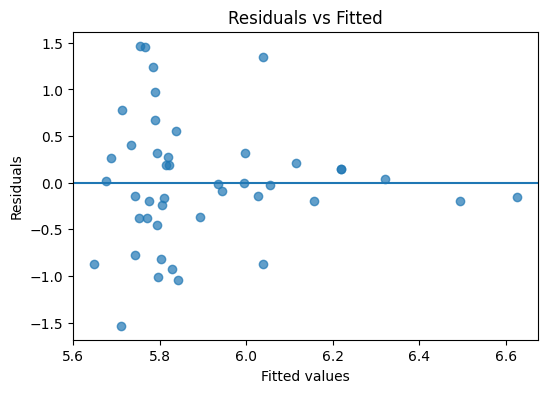

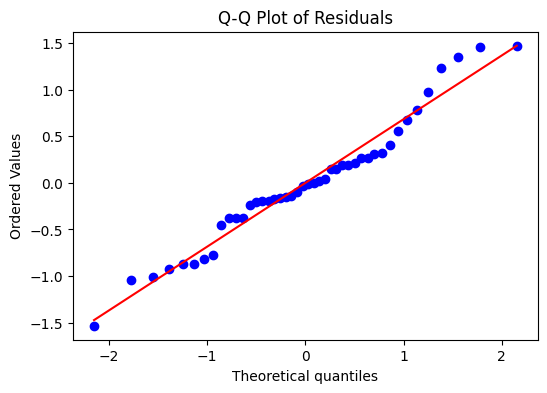

In [31]:
import scipy.stats as stats

# Get fitted values and residuals
fitted = ols_model.fittedvalues
residuals = ols_model.resid

# Residuals vs fitted plot
plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals, alpha=0.7)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# QQ plot
plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

To assess the validity of the OLS model, diagnostic plots are used to evaluate key assumptions, including linearity, homoscedasticity, and normality of residuals.

In particular, two standard diagnostic plots are examined:

Residuals versus fitted values  
Q-Q plot of residuals  

These plots help identify potential violations of model assumptions and guide possible improvements.

The residuals versus fitted values plot does not show a strong systematic pattern, suggesting that the linearity assumption is not clearly violated. The residuals appear to be roughly scattered around zero, although there is some variation in spread, indicating mild heteroscedasticity.

The Q-Q plot shows that residuals follow the theoretical normal line quite closely, especially in the central region. There are slight deviations in the tails, which may indicate minor departures from normality, but these are not severe.

Overall, the OLS assumptions appear to be approximately satisfied, although not perfectly. In particular, the presence of mild heteroscedasticity and potential outliers suggests that standard errors may not be fully reliable.

As a next step, one could consider using robust standard errors to account for heteroscedasticity, or applying a transformation to the dependent variable (such as a log transformation) to stabilize variance. Alternatively, a different outcome specification or model could be explored if stronger predictive relationships are desired.

## Part 4: Ecological Fallacy

An individual level association refers to a relationship observed between variables measured at the level of individuals, such as whether a person’s characteristics (e.g., nationality, age, or education) are associated with their own health outcomes. In contrast, an ecological association is observed using aggregated data, where the unit of analysis is a group—such as a comuna rather than individuals. In this case, variables represent averages or proportions within each comuna (e.g., percentage of foreign-born population or average hospitalization rates). The key difference is that ecological associations describe patterns across groups, not within individuals, and therefore cannot be directly interpreted as individual-level relationships.

A clear example from the results is the positive association between `pct_foreign_clean` and ENO notification rates observed in the Poisson model. At the ecological level, this suggests that comunas with higher shares of foreign-born population tend to have higher ENO notification rates. However, a misinterpretation would be to conclude that foreign-born individuals are more likely to be notified than Chilean-born individuals. This would be an ecological fallacy, as the data do not track individual outcomes. The observed pattern could instead reflect other comuna level factors, such as differences in reporting practices, population density, access to healthcare, or the presence of major hospitals that serve broader populations.

Despite this limitation, ecological associations remain useful for public-health planning. For instance, even if we cannot conclude that foreign-born individuals have a higher individual risk, the observed relationship between `pct_foreign_clean` and ENO rates can still help identify comunas where disease notifications are more frequent. This information can guide resource allocation, such as targeting testing campaigns, strengthening local healthcare capacity, or improving surveillance systems in specific areas. In this sense, ecological analysis is valuable for identifying high risk locations, even if it does not explain individual-level mechanisms.

Beyond the ecological fallacy, there are additional threats to inference in this analysis. One important issue is omitted variable bias. The models include a limited set of demographic covariates, but many relevant factors such as healthcare infrastructure, environmental conditions, or income inequality are not captured. If these omitted variables are correlated with both the predictors and the outcomes, the estimated coefficients may be biased. Another concern is measurement error, particularly in the ENO dataset, where some comuna information is anonymized or missing. This can introduce noise and reduce the reliability of the estimated relationships. Additionally, the relatively small sample size (around 44 comunas) limits statistical power and increases sensitivity to outliers.

In future work, these issues could be addressed by incorporating richer datasets, including more detailed socioeconomic and healthcare variables, and by using spatial models to account for geographic dependence between comunas. Individual level data, if available, would allow for a more direct analysis of causal relationships and avoid the limitations inherent in ecological inference.

## Part 5: Spatial Visualization of Model Output 

### 5.1 Predicted-rate map

Using the preferred Negative Binomial model from Part 2, predicted ENO notification rates per 10,000 inhabitants are computed for each comuna.

The predicted values are derived from the model-predicted ENO counts and then standardized by total population. A choropleth map is used to visualize the spatial distribution of predicted notification rates across comunas.

In [32]:
import geopandas as gpd

# Load comuna shapefile
gdf = gpd.read_file("comunas.shp")

# Inspect columns and first rows
print(gdf.columns)
gdf.head()

Index(['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna',
       'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna',
       'Provincia', 'geometry'],
      dtype='str')


,objectid,shape_leng,dis_elec,cir_sena,cod_comuna,codregion,st_area_sh,st_length_,Region,Comuna,Provincia,geometry
0,48,170038.624165,16,8,6204,6,9.685774e+08,206184.271675,Región del Libertador Bernardo O'Higgins,Marchigüe,Cardenal Caro,"POLYGON ((-7992818.789 -4056669.319, -7992731...."
1,29,125730.104795,15,8,6102,6,4.157446e+08,151911.576827,Región del Libertador Bernardo O'Higgins,Codegua,Cachapoal,"POLYGON ((-7831651.813 -4022443.109, -7831596...."
2,30,63026.084422,15,8,6103,6,1.448565e+08,76355.326122,Región del Libertador Bernardo O'Higgins,Coinco,Cachapoal,"POLYGON ((-7892616.357 -4060673.364, -7892621...."
3,31,89840.903562,15,8,6104,6,3.256572e+08,108874.623150,Región del Libertador Bernardo O'Higgins,Coltauco,Cachapoal,"POLYGON ((-7906457.717 -4051723.734, -7906266...."
4,78,122626.493264,23,11,9121,9,6.990727e+08,156680.410681,Región de La Araucanía,Cholchol,Cautín,"POLYGON ((-8121756.186 -4645860.295, -8121644...."


In [36]:
# Create a copy of the analytical dataframe
df_map = df.copy()

# Initialize prediction columns
df_map["predicted_eno"] = np.nan
df_map["predicted_rate_10k"] = np.nan

# Predict expected ENO counts only for rows used in the Negative Binomial model
df_map.loc[model_df.index, "predicted_eno"] = nb_model.predict(X, offset=offset)

# Convert predicted counts into predicted rates per 10,000 inhabitants
df_map["predicted_rate_10k"] = (
    df_map["predicted_eno"] / df_map["pop_total"]
) * 10000

# Check result
df_map[["codigo_comuna", "nombre_comuna_census", "predicted_eno", "predicted_rate_10k"]].head()

,codigo_comuna,nombre_comuna_census,predicted_eno,predicted_rate_10k
0,5101,Valparaíso,2722.017273,95.530160
1,5102,Casablanca,416.539556,139.422800
2,13101,Santiago,NaN,NaN
3,13102,Cerrillos,919.783383,108.157640
4,13104,Conchalí,884.172440,72.719324


In [37]:
# Filter only Región Metropolitana
gdf_rm = gdf[gdf["codregion"] == 13].copy()

# Make sure merge keys have the same type
gdf_rm["cod_comuna"] = gdf_rm["cod_comuna"].astype(int)
df_map["codigo_comuna"] = df_map["codigo_comuna"].astype("Int64")

# Merge shapefile with predicted rates
gdf_pred = gdf_rm.merge(
    df_map,
    left_on="cod_comuna",
    right_on="codigo_comuna",
    how="left"
)

print("RM comunas in shapefile:", gdf_rm.shape[0])
print("Rows after merge:", gdf_pred.shape[0])
print("Missing predicted rates:", gdf_pred["predicted_rate_10k"].isna().sum())

gdf_pred[["cod_comuna", "Comuna", "predicted_rate_10k"]].head()

RM comunas in shapefile: 52
Rows after merge: 52
Missing predicted rates: 10


,cod_comuna,Comuna,predicted_rate_10k
0,13129,San Joaquín,NaN
1,13130,San Miguel,118.625675
2,13131,San Ramón,83.119313
3,13108,Independencia,166.482901
4,13109,La Cisterna,77.612016


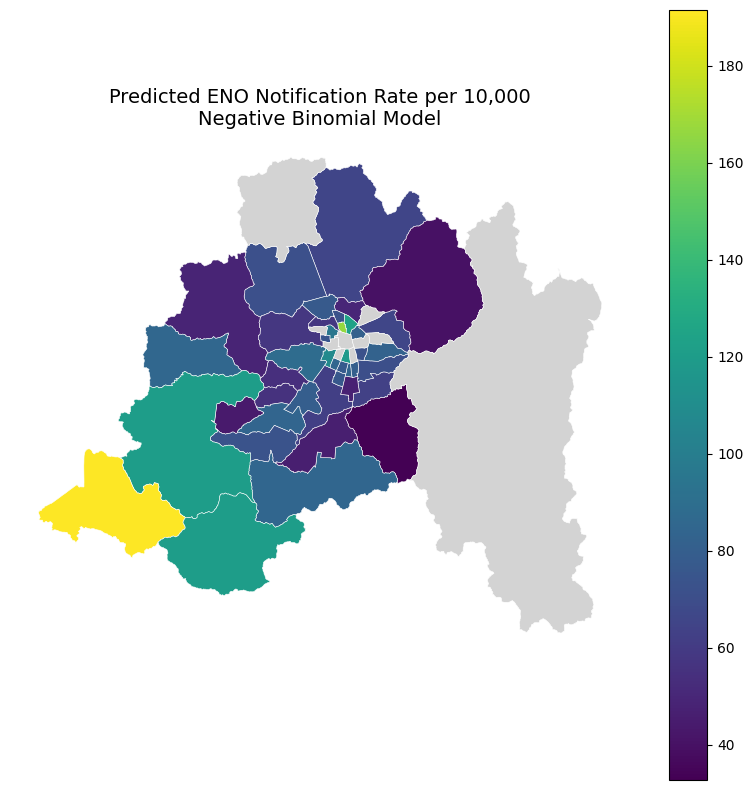

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

gdf_pred.plot(
    column="predicted_rate_10k",
    cmap="viridis",
    linewidth=0.4,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "Missing data"
    }
)

ax.set_title(
    "Predicted ENO Notification Rate per 10,000\nNegative Binomial Model",
    fontsize=14
)
ax.axis("off")

plt.show()

The choropleth map displays the predicted ENO notification rates per 10,000 inhabitants across comunas in the Región Metropolitana, based on the Negative Binomial model.

A spatial pattern can be observed. Higher predicted rates appear in a small number of comunas, particularly in some western and central areas, while lower predicted rates are more common in peripheral comunas. This suggests some geographic variation in predicted ENO notifications.

The presence of several comunas with missing values reflects the fact that not all comunas were included in the estimation sample, either due to missing covariates or data limitations. These areas are shown in grey and should be interpreted with caution.

Overall, the spatial distribution shows heterogeneity across comunas, although the underlying relationships identified in the regression analysis were not statistically strong. This indicates that the predicted patterns should be interpreted as descriptive rather than causal.

Notably, the highest predicted rates are concentrated in specific comunas, which may reflect localized factors such as healthcare access, reporting intensity, or population composition.

### 5.2 Residual map

Pearson residuals from the Negative Binomial model are computed to evaluate how well the model fits each comuna.

These residuals measure the difference between observed and predicted ENO counts, scaled by the model-implied variance. A choropleth map is used to visualize their spatial distribution, using a diverging color palette centered at zero.

In [39]:
# Compute Pearson residuals from the Negative Binomial model
df_map["pearson_residuals"] = np.nan

df_map.loc[model_df.index, "pearson_residuals"] = (
    (model_df["eno_total"] - df_map.loc[model_df.index, "predicted_eno"]) /
    np.sqrt(df_map.loc[model_df.index, "predicted_eno"])
)

# Check
df_map[["codigo_comuna", "nombre_comuna_census", "pearson_residuals"]].head()

,codigo_comuna,nombre_comuna_census,pearson_residuals
0,5101,Valparaíso,40.231241
1,5102,Casablanca,-5.122153
2,13101,Santiago,NaN
3,13102,Cerrillos,-9.159325
4,13104,Conchalí,8.401791


In [40]:
gdf_resid = gdf_rm.merge(
    df_map,
    left_on="cod_comuna",
    right_on="codigo_comuna",
    how="left"
)

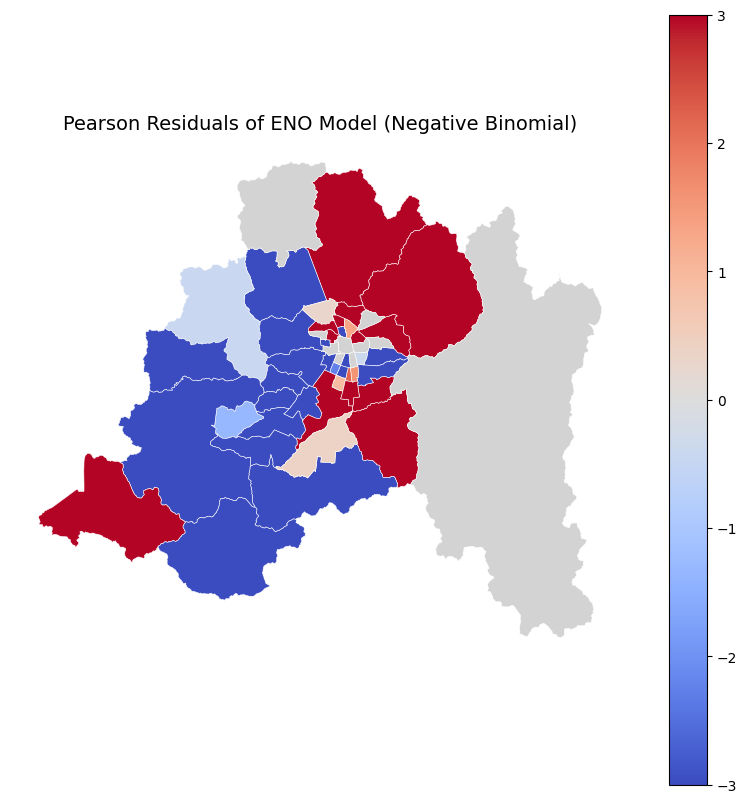

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

gdf_resid.plot(
    column="pearson_residuals",
    cmap="coolwarm",  # diverging palette
    linewidth=0.4,
    edgecolor="white",
    legend=True,
    ax=ax,
    vmin=-3, vmax=3,  # center visually at zero
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Pearson Residuals of ENO Model (Negative Binomial)", fontsize=14)
ax.axis("off")

plt.show()

The residual map highlights spatial variation in model fit across comunas.

The largest positive residuals are observed in comunas such as Huechuraba, Conchalí, and Estación Central, indicating that the model underpredicts ENO notifications in these areas. This may reflect local factors such as healthcare access, reporting intensity, or population dynamics not captured by the included covariates.

In contrast, comunas like Cerrillos and several western areas exhibit large negative residuals, meaning that the model overpredicts ENO notifications there. This may reflect lower observed disease incidence or differences in reporting relative to model expectations.

Overall, the spatial clustering of residuals suggests that the model does not fully capture geographic variation in ENO notifications. These patterns indicate that additional variables or spatial structure could improve model performance.

Some residuals are relatively large, which further suggests that unexplained variation remains in the data.

### 5.3 Coefficient plot

A coefficient plot (forest plot) is constructed for the preferred Negative Binomial model.

Each covariate is represented by its incidence rate ratio (IRR) and corresponding 95% confidence interval. The x-axis is shown on a log scale, and a vertical reference line at IRR = 1 indicates the null effect.

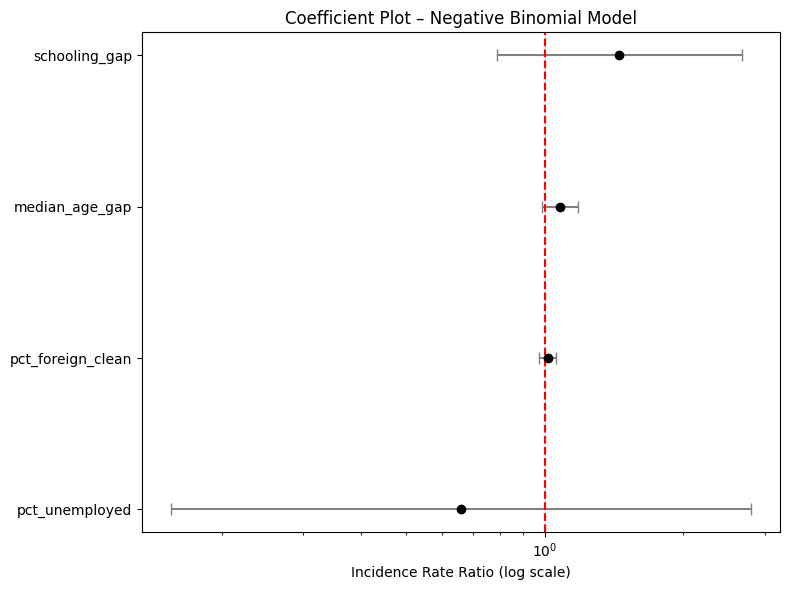

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Extract coefficients and confidence intervals
params = nb_model.params
conf = nb_model.conf_int()

# Convert to IRR
irr = np.exp(params)
ci_lower = np.exp(conf[0])
ci_upper = np.exp(conf[1])

# Create dataframe for plotting (exclude intercept)
coef_df = (
    pd.DataFrame({
        "IRR": irr,
        "CI_lower": ci_lower,
        "CI_upper": ci_upper
    })
    .drop(index="const")
    .sort_values("IRR")
)

# Plot
plt.figure(figsize=(8,6))

y_pos = np.arange(len(coef_df))

plt.errorbar(
    coef_df["IRR"],
    y_pos,
    xerr=[coef_df["IRR"] - coef_df["CI_lower"],
          coef_df["CI_upper"] - coef_df["IRR"]],
    fmt="o",
    color="black",
    ecolor="gray",
    capsize=4
)

# Vertical line at null (IRR = 1)
plt.axvline(x=1, color="red", linestyle="--")

plt.yticks(y_pos, coef_df.index)
plt.xscale("log")  # IMPORTANT
plt.xlabel("Incidence Rate Ratio (log scale)")
plt.title("Coefficient Plot – Negative Binomial Model")

plt.grid(True, axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

The coefficient plot summarizes the estimated incidence rate ratios (IRR) and their 95% confidence intervals for the Negative Binomial model.

Most covariates have confidence intervals that cross the null value (IRR = 1), indicating that their effects are not statistically significant once overdispersion is accounted for. In particular, pct_foreign_clean is close to 1 with a relatively narrow interval, suggesting a weak or negligible association.

The schooling_gap variable shows a point estimate above 1, but its confidence interval is wide and overlaps the null, indicating substantial uncertainty. The pct_unemployed variable exhibits the widest confidence interval, reflecting high variability and low precision in its estimated effect.

The median_age_gap coefficient is slightly above 1, but its confidence interval also overlaps the null, indicating that the effect is not statistically distinguishable from zero.

Overall, the coefficient plot reinforces the conclusion that, after correcting for overdispersion, there is limited statistical evidence of strong associations between the included covariates and ENO notification counts.

## Part 6: Integrated Synthesis

Part 6: Integrated Synthesis

1. Demographic portrait of the Región Metropolitana

The demographic structure of the Región Metropolitana shows substantial heterogeneity at the comuna level, with a clear dominant axis of variation driven by socioeconomic conditions and population composition. From Tarea 1, comunas differ significantly in terms of percentage of foreign-born population, schooling levels, employment rates, and age structure.

One of the most salient dimensions is the variation in pct_foreign, which ranges from values around 5% in comunas such as Buin to above 40% in others. This variation is closely associated with differences in education and labor market outcomes: comunas with higher shares of foreign-born population tend to exhibit higher mean years of schooling among foreigners and higher employment rates compared to Chilean-born populations. At the same time, gaps such as schooling_gap and emp_gap highlight inequalities between population groups within comunas.

Overall, this suggests that comunas can be positioned along a gradient that combines socioeconomic development, labor market integration, and demographic composition. Central and more economically dynamic comunas tend to have higher population density, higher schooling levels, and a larger share of foreign-born residents, while peripheral comunas tend to have lower values across these dimensions.

2. Mapping the health landscape onto the demographic axis

The health landscape from Tarea 2 partially aligns with this demographic axis, but the relationship is far from uniform. ENO notification rates and GRD hospitalization outcomes show variation across comunas that sometimes reflects demographic differences, but also reveals important mismatches.

For ENO, comunas with higher pct_foreign_clean often display higher notification rates, which is consistent with the positive association observed in the correlation matrix (approximately 0.22). However, this pattern is not consistent across all comunas, as shown in the scatter plots. Some areas with moderate demographic indicators still show elevated ENO rates, while others with similar demographic profiles exhibit lower rates. This suggests that factors beyond population composition such as reporting practices, healthcare access, or exposure risks play an important role.

For GRD outcomes, the alignment with demographic variables is even weaker. Variables such as grd_rate_per_10k and grd_mean_los do not show a consistent relationship with the demographic gradients identified in Tarea 1, with correlations generally close to zero. This indicates that hospitalization patterns are influenced by additional structural factors, including hospital availability, referral systems, and case severity, rather than solely by population composition.

These mismatches highlight that while demographic characteristics provide a useful lens, they are insufficient to fully explain the observed health outcomes across comunas.

3. Added value of cross-dataset models

The cross-dataset models in Tarea 3 provide important insights beyond what is visible in simple correlations or descriptive analysis. While the correlation matrix suggested moderate relationships such as a positive association between pct_foreign_clean and ENO notification rates the regression results reveal that these associations are not robust once overdispersion is properly accounted for.

In particular, the Poisson model initially indicated strong and statistically significant effects for several covariates. However, the dispersion statistic was extremely high (approximately 156), indicating severe overdispersion. After switching to the Negative Binomial model, most coefficients lost statistical significance, and their confidence intervals widened substantially. This demonstrates that variability across comunas is much larger than what a Poisson model assumes, and that naive interpretations based on it would have been misleading.

Additionally, the spatial visualizations provide insights that are not captured by regression coefficients alone. The predicted rate map reveals clusters of higher expected ENO rates in specific areas of the Región Metropolitana, while the residual map shows systematic patterns of underprediction and overprediction. For example, comunas such as Huechuraba exhibit large positive residuals, indicating that the model fails to capture important local drivers of ENO notifications, while others such as Cerrillos show negative residuals, suggesting overprediction.

These spatial patterns suggest that omitted variables potentially related to healthcare infrastructure, population mobility, or reporting intensity are geographically structured. Such findings would not have been apparent from any single dataset or from correlation analysis alone.

Final synthesis

Taken together, the results from Tareas 1, 2, and 3 show that demographic composition is an important but incomplete determinant of health outcomes at the comuna level. While there is some alignment between demographic gradients and ENO notification rates, the relationship is neither uniform nor robust once model uncertainty and overdispersion are considered.

The analysis highlights the importance of integrating multiple data sources and methodological approaches. Descriptive statistics reveal broad patterns, regression models test their robustness, and spatial analysis uncovers localized deviations. At the same time, the results underscore the limitations of ecological analysis and the need for richer data and more sophisticated models to fully understand the drivers of health variation across comunas.